# **TS1: Síntesis y operaciones de señales**

## Ejercicio 1: Generación y análisis de señales

En este ejercicio se generan distintas señales discretas y se analiza su contenido en frecuencia mediante la Transformada de Fourier.

Se utilizan siempre `N = 1000` muestras. Para la señal de 2 kHz se selecciona una frecuencia de muestreo de `fs = 20 kHz`, lo que permite obtener 10 muestras por período y cumplir con la condición solicitada.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

In [6]:
# Definiciones
N = 1000

# Para tener al menos 10 puntos por período: fs >= 10 * 2000 Hz
fs = 20000  # Hz

# Funciones

def mi_funcion_sen(vmax, dc, ff, ph, nn=N, fs=fs):  
    tt = np.arange(nn) / fs    
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)    
    return tt, xx

def funcion_fft(xx, fs):    
    XX = np.fft.fft(xx)
    ff = np.fft.fftfreq(len(xx), 1/fs)    
    return ff, XX

### 1. Señal sinusoidal de 2 kHz

Se genera una señal sinusoidal de frecuencia `f₀ = 2 kHz`.

Para obtener al menos 10 muestras por período se utiliza una frecuencia de muestreo de `fs = 20 kHz`, ya que:

$$
\frac{f_s}{f_0} = \frac{20000}{2000} = 10
$$

Por lo tanto, se obtienen 10 muestras por cada período de la señal.

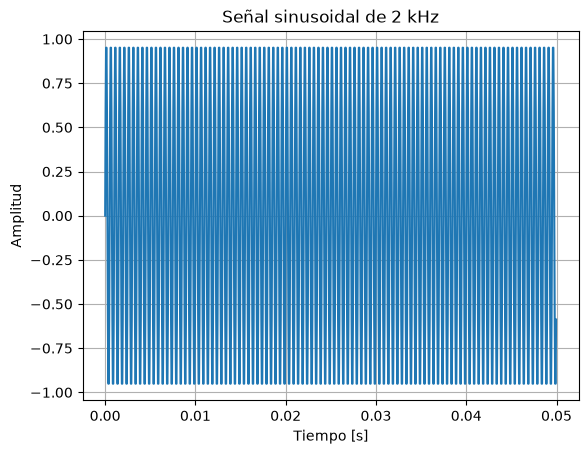

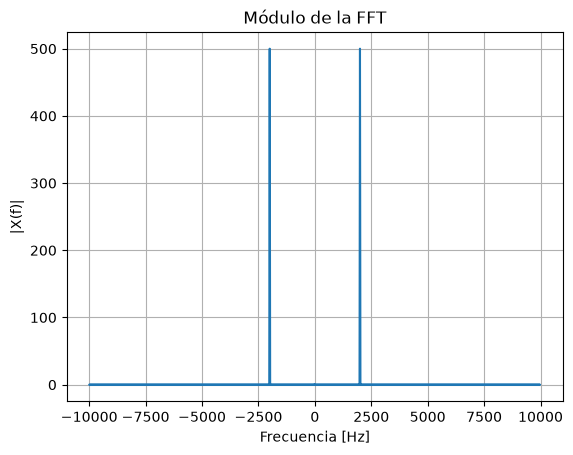

In [13]:
ff_sen = 2000
vmax = 1
dc = 0
ph = 0

tt, xx = mi_funcion_sen(vmax, dc, ff_sen, ph)

ff_fft, XX = funcion_fft(xx, fs)

plt.figure()
plt.plot(tt, xx)
plt.title("Señal sinusoidal de 2 kHz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

plt.figure()
plt.plot(ff_fft, np.abs(XX))
plt.title("Módulo de la FFT")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X(f)|")
plt.grid()
plt.show()

### 2. Señal sinusoidal de 2 W y desfase π/2

Para una señal sinusoidal de amplitud pico $A$ y valor medio cero, la potencia media es:

$$
P = \frac{A^2}{2}
$$

Como se desea una potencia de 2 W:

$$
A = \sqrt{2P} = \sqrt{4} = 2
$$

Además, se agrega un desfase de $\pi/2$ radianes.

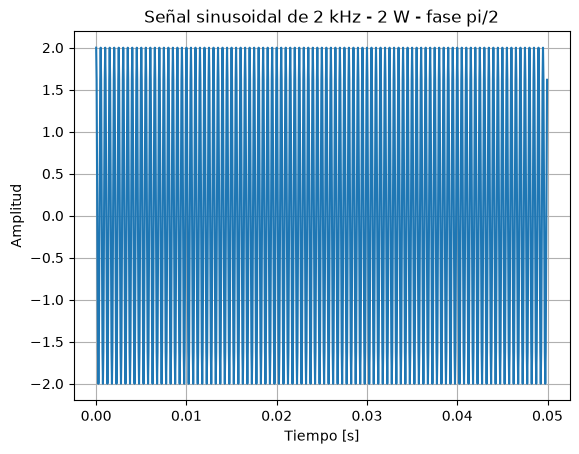

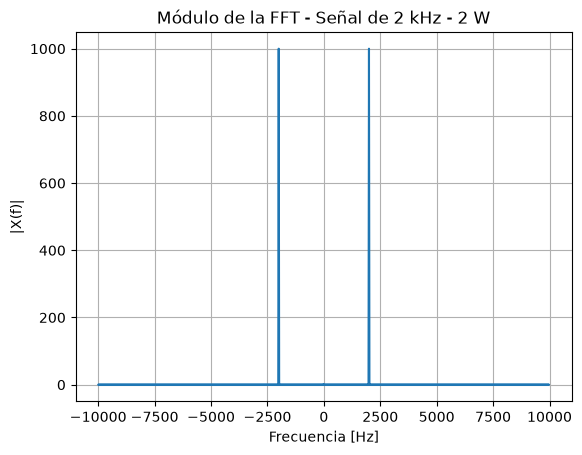

In [9]:
potencia = 2

# P = A^2 / 2
vmax = np.sqrt(2 * potencia)

dc = 0
ph = np.pi / 2

tt, xx = mi_funcion_sen(vmax, dc, ff_sen, ph)

ff_fft, XX = funcion_fft(xx, fs)

plt.figure()
plt.plot(tt, xx)
plt.title("Señal sinusoidal de 2 kHz - 2 W - fase pi/2")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

plt.figure()
plt.plot(ff_fft, np.abs(XX))
plt.title("Módulo de la FFT - Señal de 2 kHz - 2 W")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X(f)|")
plt.grid()
plt.show()

### 3. Ruido normalmente distribuido

Se genera una secuencia de ruido con distribución normal, valor medio de 0 V y varianza de 0.1 W.

En una distribución normal, el parámetro `scale` corresponde al desvío estándar, por lo que:

$$
\sigma = \sqrt{0.1}
$$

El ruido se genera con media 0 y este desvío estándar.

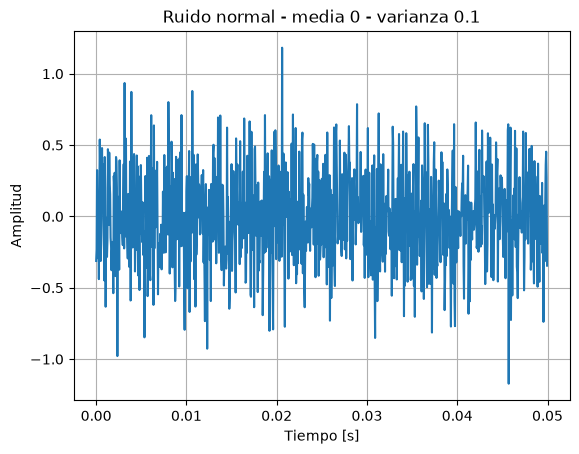

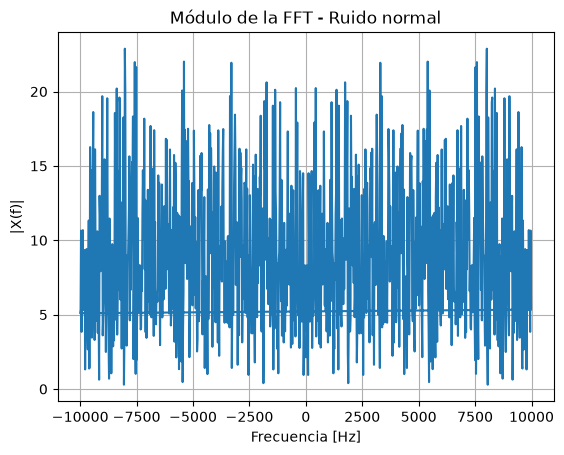

In [10]:
media = 0
varianza = 0.1
desvio = np.sqrt(varianza)

ruido_normal = np.random.normal(
    loc=media,
    scale=desvio,
    size=N
)

tt = np.arange(N) / fs

ff_fft, XX = funcion_fft(ruido_normal, fs)

plt.figure()
plt.plot(tt, ruido_normal)
plt.title("Ruido normal - media 0 - varianza 0.1")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

plt.figure()
plt.plot(ff_fft, np.abs(XX))
plt.title("Módulo de la FFT - Ruido normal")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X(f)|")
plt.grid()
plt.show()

### 4. Ruido uniformemente distribuido

Se genera una secuencia de ruido con distribución uniforme, valor medio 0 V y varianza 0.1 W.

Para una distribución uniforme entre $-L$ y $L$, la varianza es:

$$
\sigma^2 = \frac{L^2}{3}
$$

Por lo tanto:

$$
L = \sqrt{3\sigma^2} = \sqrt{3 \cdot 0.1}
$$

In [ ]:
limite = np.sqrt(3 * varianza)

ruido_uniforme = np.random.uniform(
    low=-limite,
    high=limite,
    size=N
)

ff_fft, XX = mi_fft(ruido_uniforme, fs)


plt.figure()
plt.plot(tt, ruido_uniforme)
plt.title("Ruido uniforme - media 0 - varianza 0.1")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.show()


plt.figure()
plt.plot(ff_fft, np.abs(XX))
plt.title("Módulo de la FFT - Ruido uniforme")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X(f)|")
plt.grid()
plt.show()

### 5. Pulso rectangular

Se genera un pulso rectangular de frecuencia 2 kHz y ciclo de actividad del 50%.

Para un pulso que toma valores entre 0 y $A$, su potencia media es:

$$
P = D A^2
$$

donde $D$ es el ciclo de actividad.

Como $P = 1$ W y $D = 0.5$:

$$
A = \sqrt{\frac{P}{D}} = \sqrt{2}
$$

Para generar la señal se utiliza la función `square()` de `scipy.signal`.

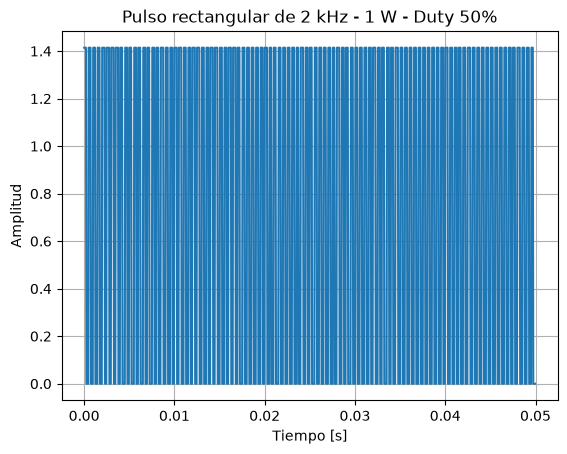

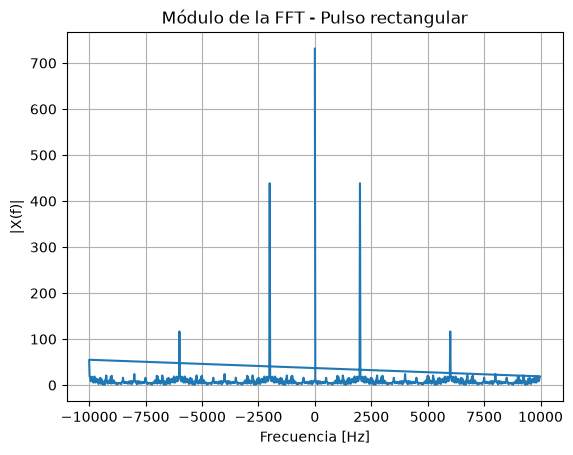

In [12]:
potencia = 1
duty = 0.5

# Para un pulso entre 0 y A:
# P = duty * A^2
amplitud = np.sqrt(potencia / duty)

tt = np.arange(N) / fs

pulso = amplitud * (
    signal.square(2 * np.pi * ff_sen * tt, duty=duty) + 1
) / 2

ff_fft, XX = funcion_fft(pulso, fs)

plt.figure()
plt.plot(tt, pulso)
plt.title("Pulso rectangular de 2 kHz - 1 W - Duty 50%")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

plt.figure()
plt.plot(ff_fft, np.abs(XX))
plt.title("Módulo de la FFT - Pulso rectangular")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X(f)|")
plt.grid()
plt.show()

### Análisis en frecuencia

Para cada señal se calcula la Transformada Discreta de Fourier (DFT) utilizando `numpy.fft`.

Se representa el módulo de la transformada:

$$
|X[k]|
$$

Esto permite observar qué frecuencias componen cada señal. En el caso de la señal sinusoidal de 2 kHz, se espera observar un pico alrededor de esa frecuencia.